## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import pickle

## Step 2: Load Dataset

In [2]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 3: Basic Inspection

In [3]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.describe())

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000

## Step 4: Feature Engineering

In [4]:
df["Car_Age"] = 2025 - df["Year"]

In [5]:
df["Brand"] = df["Car_Name"].apply(
    lambda x: x.split()[0].lower()
)

In [6]:
df.drop(
    ["Car_Name","Year"],
    axis=1,
    inplace=True
)

## Step 5: EDA

Selling Price Distribution

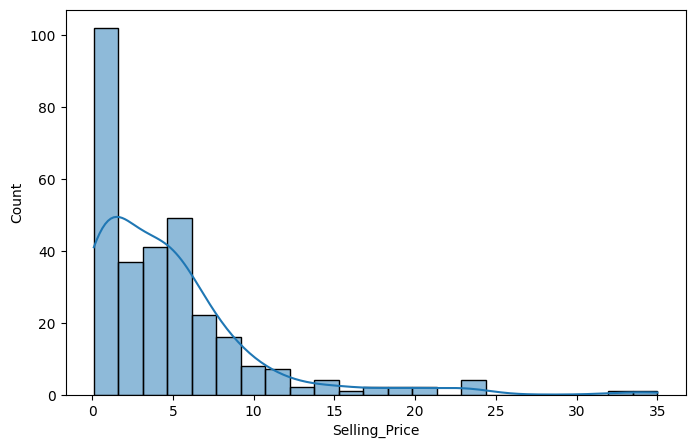

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Selling_Price"],
    kde=True
)

plt.show()

Correlation Heatmap

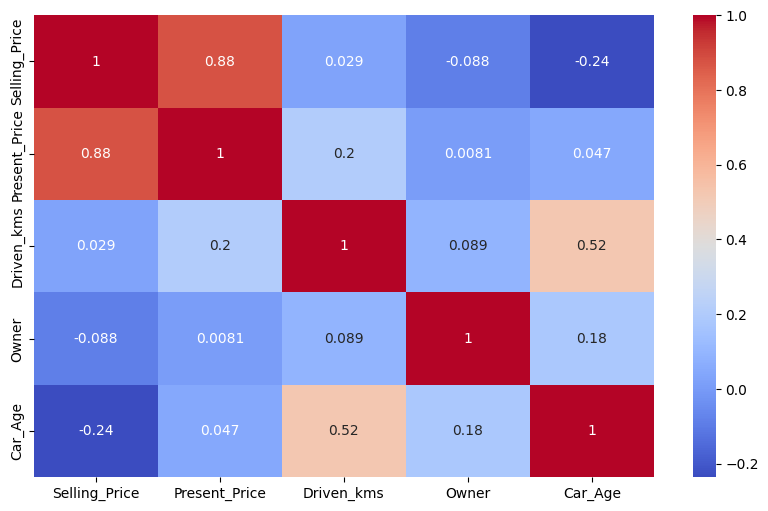

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Fuel Type vs Selling Price

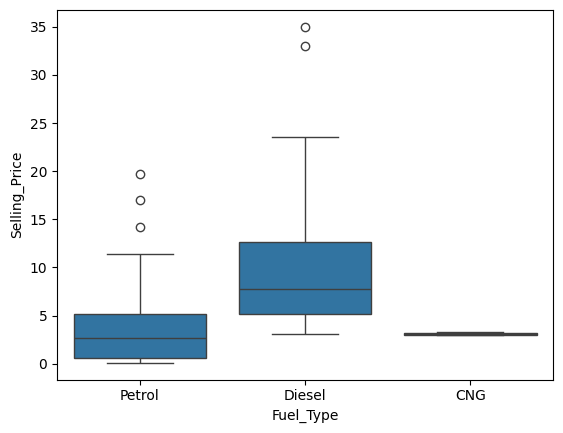

In [9]:
sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.show()

Transmission vs Selling Price

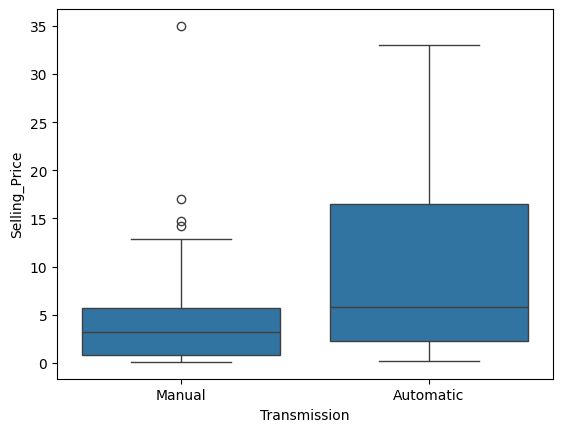

In [10]:
sns.boxplot(
    x="Transmission",
    y="Selling_Price",
    data=df
)

plt.show()

## Step 6: Features & Target

In [11]:
X = df.drop(
    "Selling_Price",
    axis=1
)

y = df["Selling_Price"]

## Step 7: Categorical & Numerical Columns

In [12]:
cat_cols = [
    "Brand",
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

num_cols = [
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age"
]

## Step 8: Preprocessing

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        ),
        (
            "num",
            "passthrough",
            num_cols
        )
    ]
)

## Step 9: Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Step 10: Random Forest Model

In [15]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),

    ("model",
     RandomForestRegressor(
         n_estimators=500,
         max_depth=10,
         random_state=42
     ))
])

In [16]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Brand', 'Fuel_Type',
                                                   'Selling_type',
                                                   'Transmission']),
                                                 ('num', 'passthrough',
                                                  ['Present_Price',
                                                   'Driven_kms', 'Owner',
                                                   'Car_Age'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=500,
                                       random_state=42))])

## Step 11: Prediction

In [17]:
pred = rf_model.predict(X_test)

## Step 12: Evaluation

In [18]:
r2 = r2_score(
    y_test,
    pred
)

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print("R2 Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 Score : 0.9611774754134784
MAE : 0.6258379583239367
RMSE : 0.9456741227314327


## Step 13: Actual vs Predicted Plot

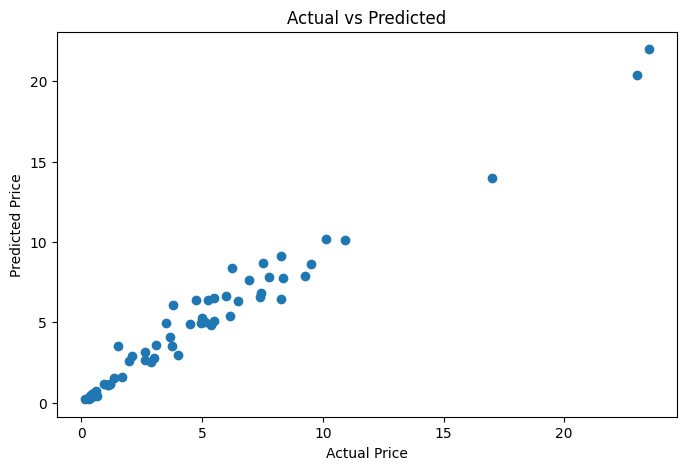

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## Step 14: Save Model

In [20]:
pickle.dump(
    rf_model,
    open(
        "car_price_model.pkl",
        "wb"
    )
)

## Step 15: Test Saved Model

In [21]:
model = pickle.load(
    open(
        "car_price_model.pkl",
        "rb"
    )
)

## Step 16: Sample Prediction

In [22]:
sample = pd.DataFrame({

    "Brand":["city"],

    "Present_Price":[8.5],

    "Driven_kms":[45000],

    "Fuel_Type":["Petrol"],

    "Selling_type":["Dealer"],

    "Transmission":["Manual"],

    "Owner":[0],

    "Car_Age":[5]

})

prediction = model.predict(sample)

print(
    "Predicted Price:",
    prediction[0]
)

Predicted Price: 7.083373599774404
